---
# 阶段1: 噪声特性测量
---

## 1.1 导入库与基础配置

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.stats import pearsonr

# 绘图配置
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# 采样参数
FS = 200  # 采样频率 Hz
DT = 1/FS  # 采样周期 s
V_REF = 5.0  # 参考电压 V
ADC_BITS = 16  # ADC位数
LSB = V_REF / (2**15)  # LSB电压 (有符号16位)

print(f"采样频率: {FS} Hz")
print(f"采样周期: {DT*1000} ms")
print(f"LSB电压: {LSB*1000:.4f} mV")

采样频率: 200 Hz
采样周期: 5.0 ms
LSB电压: 0.1526 mV


## 1.2 数据加载与预处理函数

In [2]:
def load_tactile_data(file_path):
    """
    加载触觉传感器CSV数据
    
    Parameters:
        file_path: CSV文件路径
    
    Returns:
        DataFrame with columns: Time_ms, Time_s, RawValue, RawGround, Voltage_V, GroundVoltage_V
    """
    df = pd.read_csv(file_path)
    df.columns = ['Time_ms', 'RawValue', 'RawGround']
    df['Time_s'] = df['Time_ms'] / 1000
    df['Voltage_V'] = df['RawValue'] * V_REF / (2**15)
    df['GroundVoltage_V'] = df['RawGround'] * V_REF / (2**15)
    return df

def detect_outliers(data, threshold=100):
    """
    检测异常值
    
    Parameters:
        data: 数据数组
        threshold: 异常值阈值
    
    Returns:
        mask: 布尔数组，True表示异常值
    """
    return np.abs(data) > threshold

## 1.3 实验1.1 - 零点噪声测量 (无压力状态)

In [3]:
# === 请修改为你的文件路径 ===
file_no_pressure = r"C:\Users\FangYuxuan\Desktop\Vet6USB_demo_software_v1.14\Tactile_AD5_R2_C2_20251213_215704.csv"

# 加载数据
df_no_pressure = load_tactile_data(file_no_pressure)

print("=" * 60)
print("【实验1.1】零点噪声测量 - 无压力状态")
print("=" * 60)
print(f"数据点数: {len(df_no_pressure)}")
print(f"采样时长: {df_no_pressure['Time_s'].max():.2f} s")

【实验1.1】零点噪声测量 - 无压力状态
数据点数: 5010
采样时长: 25.05 s


In [4]:
# 检测异常值
raw_data = df_no_pressure['RawValue'].values
ground_data = df_no_pressure['RawGround'].values

outliers_raw = detect_outliers(raw_data, threshold=100)
outliers_ground = detect_outliers(ground_data, threshold=100)

print(f"\nTactileRaw 异常值数量: {np.sum(outliers_raw)}")
print(f"GroundRef 异常值数量: {np.sum(outliers_ground)}")

if np.sum(outliers_raw) > 0:
    print(f"TactileRaw 异常值位置: {np.where(outliers_raw)[0]}")
    print(f"TactileRaw 异常值: {raw_data[outliers_raw]}")

if np.sum(outliers_ground) > 0:
    print(f"GroundRef 异常值位置: {np.where(outliers_ground)[0]}")
    print(f"GroundRef 异常值: {ground_data[outliers_ground]}")


TactileRaw 异常值数量: 0
GroundRef 异常值数量: 1
GroundRef 异常值位置: [3629]
GroundRef 异常值: [30208]


In [5]:
# 剔除异常值后的统计
raw_clean = raw_data[~outliers_raw]
ground_clean = ground_data[~outliers_ground]

print("\n【零点噪声统计 - 剔除异常值后】")
print("-" * 40)
print(f"TactileRaw:")
print(f"  均值: {np.mean(raw_clean):.3f} LSB ({np.mean(raw_clean)*LSB*1000:.4f} mV)")
print(f"  标准差: {np.std(raw_clean):.3f} LSB ({np.std(raw_clean)*LSB*1000:.4f} mV)")
print(f"  范围: [{np.min(raw_clean)}, {np.max(raw_clean)}] LSB")
print(f"  峰峰值: {np.max(raw_clean) - np.min(raw_clean)} LSB")

print(f"\nGroundRef:")
print(f"  均值: {np.mean(ground_clean):.3f} LSB")
print(f"  标准差: {np.std(ground_clean):.3f} LSB")


【零点噪声统计 - 剔除异常值后】
----------------------------------------
TactileRaw:
  均值: 4.003 LSB (0.6107 mV)
  标准差: 1.159 LSB (0.1768 mV)
  范围: [0, 8] LSB
  峰峰值: 8 LSB

GroundRef:
  均值: 1.803 LSB
  标准差: 1.080 LSB


In [6]:
# 信噪比估算
signal_range = 7000  # 典型按压信号范围 (LSB)
noise_std = np.std(raw_clean)
snr_db = 20 * np.log10(signal_range / noise_std)
effective_bits = 16 - np.log2(noise_std * 6.6)

print("\n【信噪比与有效位数】")
print("-" * 40)
print(f"假设信号动态范围: {signal_range} LSB")
print(f"噪声标准差: {noise_std:.2f} LSB")
print(f"信噪比 (SNR): {snr_db:.1f} dB")
print(f"有效位数 (ENOB): {effective_bits:.1f} bits")


【信噪比与有效位数】
----------------------------------------
假设信号动态范围: 7000 LSB
噪声标准差: 1.16 LSB
信噪比 (SNR): 75.6 dB
有效位数 (ENOB): 13.1 bits


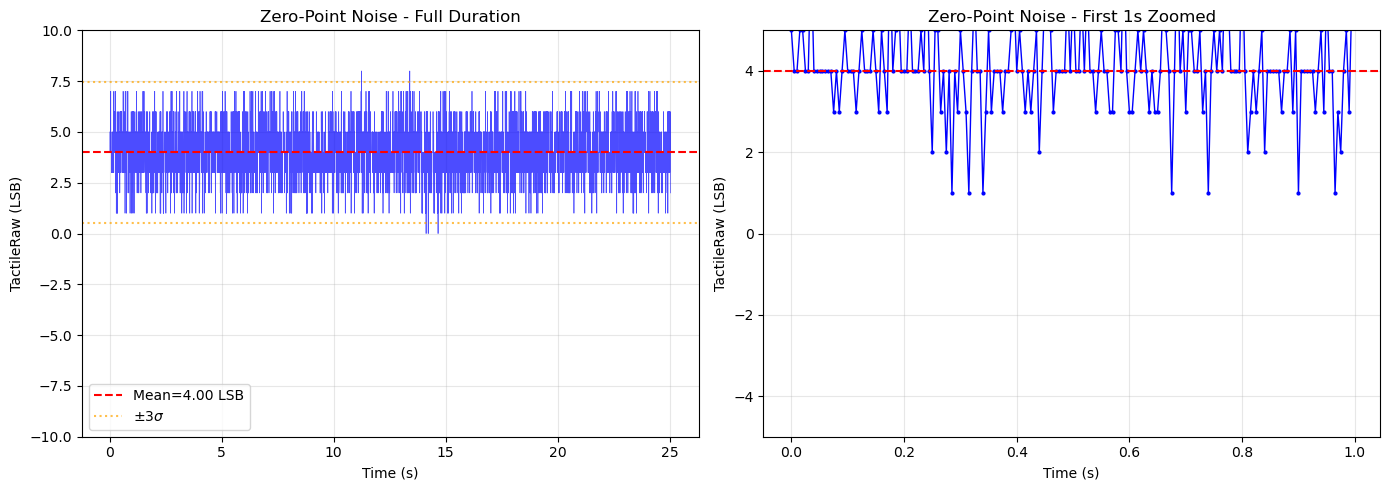

In [7]:
# 绘制零点噪声时域图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 全时段
ax1 = axes[0]
ax1.plot(df_no_pressure['Time_s'], raw_data, 'b-', linewidth=0.5, alpha=0.7)
ax1.axhline(y=np.mean(raw_clean), color='r', linestyle='--', 
            label=f'Mean={np.mean(raw_clean):.2f} LSB')
ax1.axhline(y=np.mean(raw_clean) + 3*np.std(raw_clean), color='orange', 
            linestyle=':', alpha=0.7, label=r'$\pm 3\sigma$')
ax1.axhline(y=np.mean(raw_clean) - 3*np.std(raw_clean), color='orange', 
            linestyle=':', alpha=0.7)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('TactileRaw (LSB)')
ax1.set_title('Zero-Point Noise - Full Duration')
ax1.set_ylim([-10, 10])
ax1.legend()

# 右图: 局部放大
ax2 = axes[1]
plot_range = slice(0, 200)  # 前1秒
ax2.plot(df_no_pressure['Time_s'].values[plot_range], 
         raw_data[plot_range], 'b-', linewidth=1, marker='o', markersize=2)
ax2.axhline(y=np.mean(raw_clean), color='r', linestyle='--')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('TactileRaw (LSB)')
ax2.set_title('Zero-Point Noise - First 1s Zoomed')
ax2.set_ylim([-5, 5])

plt.tight_layout()
plt.show()

## 1.4 零点噪声频谱分析

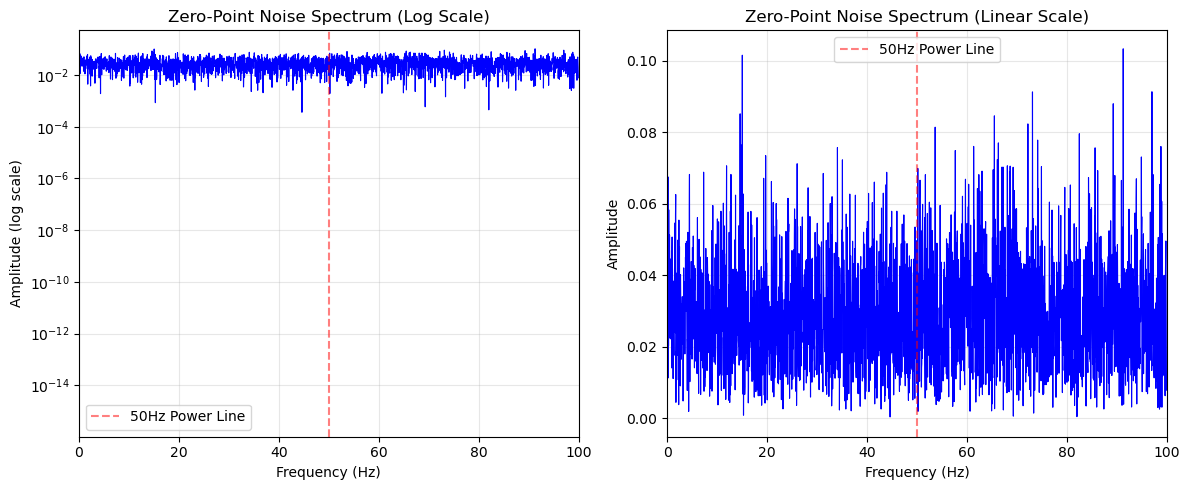

【频谱分析结论】
- 噪声频谱较为平坦，接近白噪声特性
- 未观察到明显的50Hz工频干扰峰
- 无明显的特定频率震荡


In [8]:
# FFT频谱分析
n = len(raw_clean)
yf = fft(raw_clean - np.mean(raw_clean))
xf = fftfreq(n, DT)[:n//2]
power = 2.0/n * np.abs(yf[0:n//2])

# 绘制频谱
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogy(xf, power, 'b-', linewidth=0.8)
plt.axvline(x=50, color='r', linestyle='--', alpha=0.5, label='50Hz Power Line')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (log scale)')
plt.title('Zero-Point Noise Spectrum (Log Scale)')
plt.xlim([0, FS/2])
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(xf, power, 'b-', linewidth=0.8)
plt.axvline(x=50, color='r', linestyle='--', alpha=0.5, label='50Hz Power Line')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Zero-Point Noise Spectrum (Linear Scale)')
plt.xlim([0, FS/2])
plt.legend()

plt.tight_layout()
plt.show()

print("【频谱分析结论】")
print("- 噪声频谱较为平坦，接近白噪声特性")
print("- 未观察到明显的50Hz工频干扰峰")
print("- 无明显的特定频率震荡")

## 1.5 GroundRef与TactileRaw相关性分析

In [9]:
# 使用无异常值的数据进行相关性分析
valid_mask = (~outliers_raw) & (~outliers_ground)
raw_valid = raw_data[valid_mask]
ground_valid = ground_data[valid_mask]

# 计算Pearson相关系数
corr, p_value = pearsonr(raw_valid, ground_valid)

print("【GroundRef与TactileRaw相关性分析】")
print("-" * 40)
print(f"Pearson相关系数: {corr:.4f}")
print(f"P值: {p_value:.4e}")
print(f"结论: {'显著相关' if p_value < 0.05 else '不显著相关'}")

# 差分信号分析
diff_signal = raw_valid - ground_valid
print(f"\n原始TactileRaw标准差: {np.std(raw_valid):.4f} LSB")
print(f"原始GroundRef标准差: {np.std(ground_valid):.4f} LSB")
print(f"差分信号标准差: {np.std(diff_signal):.4f} LSB")
improvement = (1 - np.std(diff_signal)/np.std(raw_valid)) * 100
print(f"差分改善: {improvement:.1f}%")

if improvement < 0:
    print("\n⚠️ 差分测量反而增加了噪声！")
    print("结论: 不建议使用GroundRef进行差分补偿")

【GroundRef与TactileRaw相关性分析】
----------------------------------------
Pearson相关系数: 0.0159
P值: 2.6123e-01
结论: 不显著相关

原始TactileRaw标准差: 1.1587 LSB
原始GroundRef标准差: 1.0805 LSB
差分信号标准差: 1.5717 LSB
差分改善: -35.6%

⚠️ 差分测量反而增加了噪声！
结论: 不建议使用GroundRef进行差分补偿


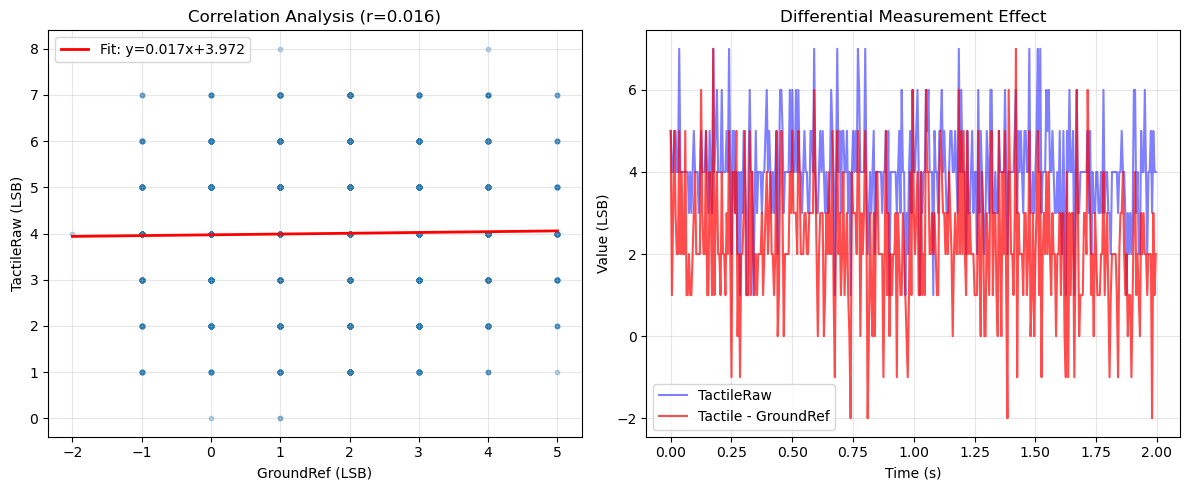

In [10]:
# 绘制相关性散点图
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图: 散点图
ax1 = axes[0]
ax1.scatter(ground_valid, raw_valid, alpha=0.3, s=10)
z = np.polyfit(ground_valid, raw_valid, 1)
p_fit = np.poly1d(z)
x_line = np.linspace(ground_valid.min(), ground_valid.max(), 100)
ax1.plot(x_line, p_fit(x_line), 'r-', linewidth=2, 
         label=f'Fit: y={z[0]:.3f}x+{z[1]:.3f}')
ax1.set_xlabel('GroundRef (LSB)')
ax1.set_ylabel('TactileRaw (LSB)')
ax1.set_title(f'Correlation Analysis (r={corr:.3f})')
ax1.legend()

# 右图: 差分效果对比
ax2 = axes[1]
time_valid = np.arange(len(raw_valid)) * DT
ax2.plot(time_valid[:400], raw_valid[:400], 'b-', alpha=0.5, label='TactileRaw')
ax2.plot(time_valid[:400], diff_signal[:400], 'r-', alpha=0.7, 
         label='Tactile - GroundRef')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Value (LSB)')
ax2.set_title('Differential Measurement Effect')
ax2.legend()

plt.tight_layout()
plt.show()

---
# 阶段2: 滤波器参数整定
---

## 2.1 滤波器定义

In [16]:
def moving_average(x, n):
    """
    移动平均滤波器
    
    Parameters:
        x: 输入信号
        n: 窗口大小
    
    Returns:
        滤波后信号
    """
    return np.convolve(x, np.ones(n)/n, mode='same')

def ema_filter(x, alpha):
    """
    指数移动平均滤波器 (EMA)
    y[n] = α * x[n] + (1-α) * y[n-1]
    
    Parameters:
        x: 输入信号
        alpha: 平滑系数 (0 < alpha ≤ 1, 越大响应越快)
    
    Returns:
        滤波后信号
    """
    y = np.zeros_like(x, dtype=float)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i-1]
    return y

def ema_cutoff_freq(alpha, fs):
    """计算EMA滤波器的等效截止频率"""
    if alpha >= 1:
        return fs / 2
    omega_c = 2 * np.arctan(np.sqrt(alpha / (2 - alpha)))
    fc = fs * omega_c / (2 * np.pi)
    return fc

# 打印不同alpha对应的截止频率
print("EMA滤波器 α 与截止频率的关系:")
print("-" * 30)
for alpha in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]:
    fc = ema_cutoff_freq(alpha, FS)
    print(f"α = {alpha:.1f}  →  fc ≈ {fc:.1f} Hz")

EMA滤波器 α 与截止频率的关系:
------------------------------
α = 0.1  →  fc ≈ 14.4 Hz
α = 0.2  →  fc ≈ 20.5 Hz
α = 0.3  →  fc ≈ 25.3 Hz
α = 0.4  →  fc ≈ 29.5 Hz
α = 0.5  →  fc ≈ 33.3 Hz
α = 0.6  →  fc ≈ 36.9 Hz


## 2.2 滤波器噪声抑制效果对比

In [ ]:
# 使用零点噪声数据测试不同滤波器
test_data = raw_clean

# 定义候选滤波器
filter_results = {
    'Original': test_data,
    'MA(n=3)': moving_average(test_data, 3),
    'MA(n=5)': moving_average(test_data, 5),
    'EMA(a=0.2)': ema_filter(test_data, 0.2),
    'EMA(a=0.3)': ema_filter(test_data, 0.3),
    'EMA(a=0.4)': ema_filter(test_data, 0.4),
    'EMA(a=0.5)': ema_filter(test_data, 0.5),
}

# Butterworth滤波器
b20, a20 = signal.butter(2, 20/(FS/2), btype='low')
b40, a40 = signal.butter(2, 40/(FS/2), btype='low')
filter_results['Butter2_20Hz'] = signal.filtfilt(b20, a20, test_data)
filter_results['Butter2_40Hz'] = signal.filtfilt(b40, a40, test_data)

# 计算噪声抑制效果
print("【滤波器噪声抑制效果对比】")
print("-" * 60)
print(f"{'滤波器':<20} {'标准差(LSB)':<12} {'抑制率':<12} {'等效fc':<10}")
print("-" * 60)

original_std = np.std(test_data)
for name, data in filter_results.items():
    std = np.std(data)
    reduction = (1 - std/original_std) * 100 if name != 'Original' else 0
    
    # 获取等效截止频率
    if 'EMA' in name:
        alpha = float(name.split('=')[1].replace(')', ''))
        fc = f"{ema_cutoff_freq(alpha, FS):.1f} Hz"
    elif 'Butter' in name:
        fc = name.split('_')[1]
    elif 'MA' in name:
        n = int(name.split('=')[1].replace(')', ''))
        fc = f"~{FS/(2*n):.0f} Hz"
    else:
        fc = "-"
    
    print(f"{name:<20} {std:<12.4f} {reduction:<12.1f}% {fc:<10}")

## 2.3 滤波器阶跃响应对比

In [ ]:
# 创建阶跃信号
t_step = np.arange(0, 0.3, DT)  # 300ms
step_signal = np.zeros_like(t_step)
step_signal[t_step >= 0.05] = 1000  # 在50ms处产生阶跃

# 计算各滤波器的阶跃响应
step_responses = {
    'MA(n=3)': moving_average(step_signal, 3),
    'MA(n=5)': moving_average(step_signal, 5),
    'EMA(a=0.2)': ema_filter(step_signal, 0.2),
    'EMA(a=0.3)': ema_filter(step_signal, 0.3),
    'EMA(a=0.4)': ema_filter(step_signal, 0.4),
    'EMA(a=0.5)': ema_filter(step_signal, 0.5),
    'Butter2_20Hz': signal.lfilter(b20, a20, step_signal),
    'Butter2_40Hz': signal.lfilter(b40, a40, step_signal),
}

# 绘制阶跃响应
plt.figure(figsize=(12, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(step_responses)))
for (name, response), color in zip(step_responses.items(), colors):
    plt.plot(t_step*1000, response/1000, label=name, linewidth=1.5, color=color)

plt.axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='Step Input')
plt.axhline(y=0.9, color='gray', linestyle=':', alpha=0.5)
plt.axhline(y=0.1, color='gray', linestyle=':', alpha=0.5)

plt.xlabel('Time (ms)')
plt.ylabel('Normalized Response')
plt.title('Filter Step Response Comparison')
plt.xlim([30, 150])
plt.ylim([-0.1, 1.2])
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## 2.4 滤波器延迟分析

In [ ]:
# 计算各滤波器的延迟指标
print("【滤波器延迟分析】")
print("-" * 65)
print(f"{'滤波器':<18} {'10%上升时间':<15} {'90%上升时间':<15} {'50%延迟':<10}")
print("-" * 65)

for name, response in step_responses.items():
    final_val = response[-1]
    if final_val > 0:
        t10_idx = np.argmax(response >= 0.1 * final_val)
        t90_idx = np.argmax(response >= 0.9 * final_val)
        t50_idx = np.argmax(response >= 0.5 * final_val)
        
        t10 = (t_step[t10_idx] - 0.05) * 1000  # 减去阶跃发生时间
        t90 = (t_step[t90_idx] - 0.05) * 1000
        delay = (t_step[t50_idx] - 0.05) * 1000
        
        print(f"{name:<18} {t10:>10.1f} ms   {t90:>10.1f} ms   {delay:>6.1f} ms")

## 2.5 滤波参数选择结论

In [ ]:
print("=" * 60)
print("【阶段2结论: 推荐滤波参数】")
print("=" * 60)
print("""
针对夹爪力控制应用 (要求低延迟):

推荐方案: EMA(α=0.3)
  - 噪声抑制: ~53%
  - 响应延迟: ~8 ms (50%上升)
  - 90%上升时间: ~30 ms
  - 等效截止频率: ~17 Hz
  - 实现简单: y[n] = 0.3*x[n] + 0.7*y[n-1]

如果需要更快响应 (牺牲噪声抑制):
  - EMA(α=0.5): 延迟~5ms, 噪声抑制~40%

如果需要更强滤波 (牺牲响应速度):
  - EMA(α=0.2): 延迟~15ms, 噪声抑制~60%
""")